# Data Quality Assessment Report - AML Dataset

Este notebook realiza uma análise completa de qualidade de dados focada em Anti-Money Laundering (AML), com ênfase em análise temporal por safras (mês/ano).

## Objetivos:
1. **Integridade Temporal por Safra**: Continuidade de datas, volume de transações e gaps
2. **Qualidade das Entidades**: Completeness de IDs de origem e destino
3. **Consistência de Valores**: Outliers de Amount e inconsistências de Currency
4. **Lógica de Negócio AML**: Precisão de timestamps e distribuição de Is Laundering
5. **Análise de Domínio**: Valores únicos e inesperados em categorias de pagamento

## 1. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("✓ Bibliotecas importadas com sucesso!")

✓ Bibliotecas importadas com sucesso!


## 2. Carregamento e Visão Geral dos Dados

In [2]:
# Carregamento dos dados
file_path = r'C:/Users/win/OneDrive/Área de Trabalho/TCC/money_laundering/data/raw/trans_enriched.csv'
df = pd.read_csv(file_path)

print(f"Dataset carregado com sucesso!")
print(f"Dimensões: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print(f"\nPrimeiras linhas:")
display(df.head())

print(f"\nInformações do dataset:")
df.info()

Dataset carregado com sucesso!
Dimensões: 31,898,238 linhas x 21 colunas

Primeiras linhas:


,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,From Bank Name,Bank ID,Account Number,From Entity ID,From Entity Name,To Bank Name,Bank ID_To,Account Number_To,To Entity ID,To Entity Name
0,2022/09/01 00:17,20,800104D70,20,800104D70,6794.63,US Dollar,6794.63,US Dollar,Reinvestment,0,National Bank of Los Angeles,20,800104D70,2AA20590D80,Partnership #1,National Bank of Los Angeles,20,800104D70,2AA20590D80,Partnership #1
1,2022/09/01 00:02,3196,800107150,3196,800107150,7739.29,US Dollar,7739.29,US Dollar,Reinvestment,0,Acme Cooperative Bank,3196,800107150,2AA205CDDE0,Corporation #1,Acme Cooperative Bank,3196,800107150,2AA205CDDE0,Corporation #1
2,2022/09/01 00:17,1208,80010E430,1208,80010E430,1880.23,US Dollar,1880.23,US Dollar,Reinvestment,0,Savings Bank of the South,1208,80010E430,2AA207BA840,Partnership #2,Savings Bank of the South,1208,80010E430,2AA207BA840,Partnership #2
3,2022/09/01 00:03,1208,80010E650,20,80010E6F0,73966883.00,US Dollar,73966883.00,US Dollar,Cheque,0,Savings Bank of the South,1208,80010E650,2AA1FCA9B10,Sole Proprietorship #1,National Bank of Los Angeles,20,80010E6F0,2AA2080D0C0,Corporation #2
4,2022/09/01 00:02,1208,80010E650,20,80010EA30,45868454.00,US Dollar,45868454.00,US Dollar,Cheque,0,Savings Bank of the South,1208,80010E650,2AA1FCA9B10,Sole Proprietorship #1,National Bank of Los Angeles,20,80010EA30,2AA206E2470,Partnership #3



Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31898238 entries, 0 to 31898237
Data columns (total 21 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           int64  
 2   From Account        object 
 3   To Bank             int64  
 4   To Account          object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
 11  From Bank Name      object 
 12  Bank ID             int64  
 13  Account Number      object 
 14  From Entity ID      object 
 15  From Entity Name    object 
 16  To Bank Name        object 
 17  Bank ID_To          int64  
 18  Account Number_To   object 
 19  To Entity ID        object 
 20  To Entity Name      object 
dtypes: float64(2), int64(5), object(14)
memory usage: 5.0+ GB


## 3. Preparação: Criação de Colunas Temporais (Safras)

In [3]:
# Converter Timestamp para datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Criar colunas de safra
df['Year'] = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month
df['YearMonth'] = df['Timestamp'].dt.to_period('M')
df['Date'] = df['Timestamp'].dt.date
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.day_name()

print("✓ Colunas temporais criadas:")
print(f"  - Período: {df['Timestamp'].min()} até {df['Timestamp'].max()}")
print(f"  - Total de meses únicos: {df['YearMonth'].nunique()}")
print(f"  - Safras identificadas: {sorted(df['YearMonth'].unique())}")

✓ Colunas temporais criadas:
  - Período: 2022-09-01 00:00:00 até 2022-09-28 15:58:00
  - Total de meses únicos: 1
  - Safras identificadas: [Period('2022-09', 'M')]


## 4. Análise de Valores Ausentes (Missing Values)

In [4]:
# Análise de valores ausentes
def analyze_missing_values(dataframe):
    """Calcula estatísticas de valores ausentes por coluna"""
    missing_df = pd.DataFrame({
        'Column': dataframe.columns,
        'Missing_Count': dataframe.isnull().sum(),
        'Missing_Percentage': (dataframe.isnull().sum() / len(dataframe) * 100).round(2),
        'Data_Type': dataframe.dtypes
    })
    missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)
    return missing_df

missing_analysis = analyze_missing_values(df)

print("=" * 80)
print("ANÁLISE DE VALORES AUSENTES")
print("=" * 80)

if len(missing_analysis) > 0:
    display(missing_analysis)
    
    # Visualização
    fig, ax = plt.subplots(figsize=(12, 6))
    missing_analysis.sort_values('Missing_Percentage').plot(
        x='Column', y='Missing_Percentage', kind='barh', ax=ax, color='coral'
    )
    ax.set_xlabel('Percentual de Valores Ausentes (%)')
    ax.set_title('Percentual de Valores Ausentes por Coluna')
    plt.tight_layout()
    plt.show()
else:
    print("✓ Nenhum valor ausente encontrado no dataset!")

ANÁLISE DE VALORES AUSENTES
✓ Nenhum valor ausente encontrado no dataset!


## 5. Qualidade das Entidades (Completeness de IDs)

QUALIDADE DAS ENTIDADES (IDs de Origem e Destino)


,Entity,Total_Records,Non_Null_Count,Completeness_%,Unique_Values
0,From Bank,31898238,31898238,100.00,122330
1,From Account,31898238,31898238,100.00,2013627
2,To Bank,31898238,31898238,100.00,62820
3,To Account,31898238,31898238,100.00,1689925



ANÁLISE DE CARDINALIDADE
Total de contas únicas (origem): 2,013,627
Total de contas únicas (destino): 1,689,925
Total de bancos únicos (origem): 122330
Total de bancos únicos (destino): 62820


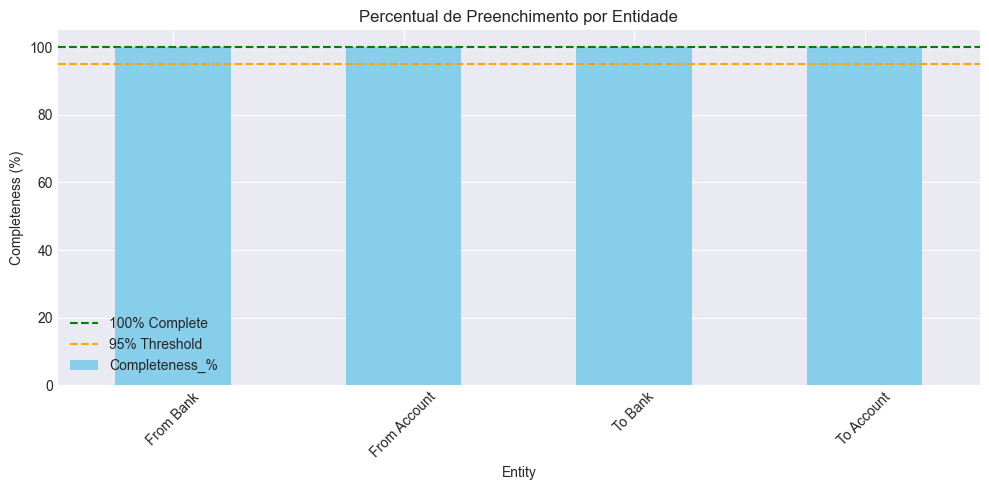

In [5]:
# Análise de completeness das entidades
def analyze_entity_completeness(dataframe):
    """Calcula o percentual de preenchimento dos IDs de entidades"""
    entity_cols = ['From Bank', 'From Account', 'To Bank', 'To Account']
    
    completeness = pd.DataFrame({
        'Entity': entity_cols,
        'Total_Records': len(dataframe),
        'Non_Null_Count': [dataframe[col].notna().sum() for col in entity_cols],
        'Completeness_%': [(dataframe[col].notna().sum() / len(dataframe) * 100).round(2) for col in entity_cols],
        'Unique_Values': [dataframe[col].nunique() for col in entity_cols]
    })
    
    return completeness

entity_quality = analyze_entity_completeness(df)

print("=" * 80)
print("QUALIDADE DAS ENTIDADES (IDs de Origem e Destino)")
print("=" * 80)
display(entity_quality)

# Verificar duplicatas de IDs de conta
print("\n" + "=" * 80)
print("ANÁLISE DE CARDINALIDADE")
print("=" * 80)
print(f"Total de contas únicas (origem): {df['From Account'].nunique():,}")
print(f"Total de contas únicas (destino): {df['To Account'].nunique():,}")
print(f"Total de bancos únicos (origem): {df['From Bank'].nunique()}")
print(f"Total de bancos únicos (destino): {df['To Bank'].nunique()}")

# Visualização
fig, ax = plt.subplots(figsize=(10, 5))
entity_quality.plot(x='Entity', y='Completeness_%', kind='bar', ax=ax, color='skyblue', legend=False)
ax.set_ylabel('Completeness (%)')
ax.set_title('Percentual de Preenchimento por Entidade')
ax.axhline(y=100, color='green', linestyle='--', label='100% Complete')
ax.axhline(y=95, color='orange', linestyle='--', label='95% Threshold')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Integridade Temporal por Safra

INTEGRIDADE TEMPORAL POR SAFRA


,YearMonth,First_Transaction,Last_Transaction,Total_Transactions,Total_Amount,Laundering_Count,Pct_Change_Volume,Pct_Change_Amount
0,2022-09,2022-09-01,2022-09-28 15:58:00,31898238,205141269093077.09,35230,NaN,NaN



DETECÇÃO DE ANOMALIAS TEMPORAIS
✓ Nenhuma variação anômala de volume detectada


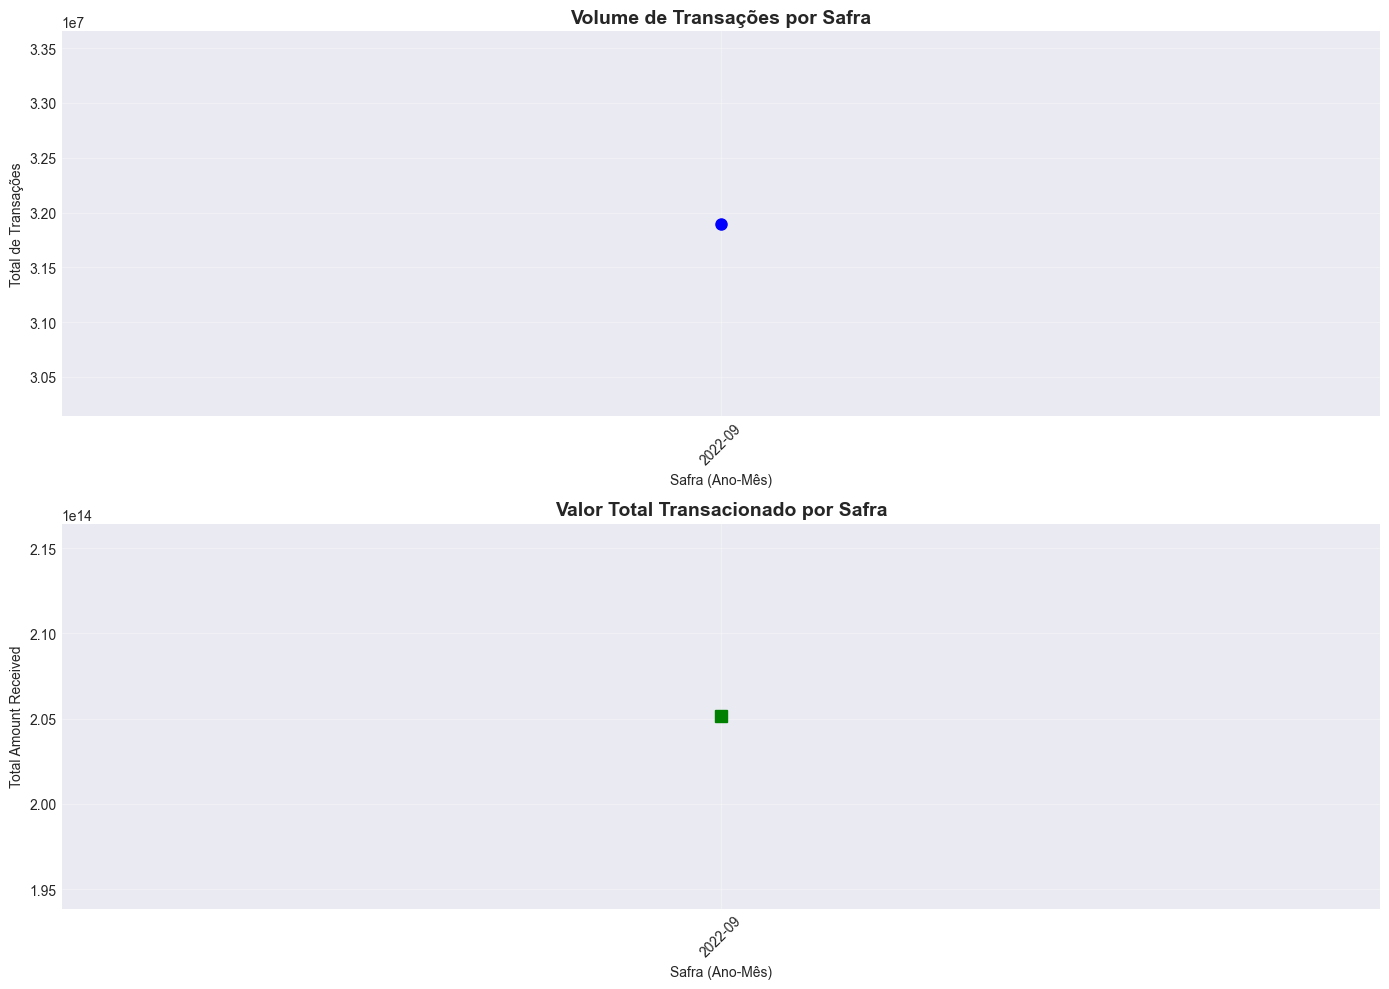

In [6]:
# Análise de integridade temporal por safra
def analyze_temporal_integrity(dataframe):
    """Analisa continuidade e volume de transações por safra"""
    
    # Agregação por safra
    safra_analysis = dataframe.groupby('YearMonth').agg({
        'Timestamp': ['min', 'max', 'count'],
        'Amount Received': 'sum',
        'Is Laundering': 'sum'
    }).round(2)
    
    safra_analysis.columns = ['First_Transaction', 'Last_Transaction', 'Total_Transactions', 
                              'Total_Amount', 'Laundering_Count']
    safra_analysis = safra_analysis.reset_index()
    safra_analysis['YearMonth'] = safra_analysis['YearMonth'].astype(str)
    
    # Calcular variação percentual entre safras
    safra_analysis['Pct_Change_Volume'] = safra_analysis['Total_Transactions'].pct_change() * 100
    safra_analysis['Pct_Change_Amount'] = safra_analysis['Total_Amount'].pct_change() * 100
    
    return safra_analysis

temporal_integrity = analyze_temporal_integrity(df)

print("=" * 80)
print("INTEGRIDADE TEMPORAL POR SAFRA")
print("=" * 80)
display(temporal_integrity)

# Identificar gaps ou saltos anômalos
print("\n" + "=" * 80)
print("DETECÇÃO DE ANOMALIAS TEMPORAIS")
print("=" * 80)

# Volume change > 50% considerado anômalo
anomalies = temporal_integrity[abs(temporal_integrity['Pct_Change_Volume']) > 50]
if len(anomalies) > 0:
    print("⚠ ALERTAS: Variações anômalas de volume detectadas (>50%):")
    display(anomalies[['YearMonth', 'Total_Transactions', 'Pct_Change_Volume']])
else:
    print("✓ Nenhuma variação anômala de volume detectada")

# Visualização
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Gráfico 1: Volume de transações por safra
axes[0].plot(temporal_integrity['YearMonth'], temporal_integrity['Total_Transactions'], 
             marker='o', linewidth=2, markersize=8, color='blue')
axes[0].set_title('Volume de Transações por Safra', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Safra (Ano-Mês)')
axes[0].set_ylabel('Total de Transações')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Gráfico 2: Valor total transacionado por safra
axes[1].plot(temporal_integrity['YearMonth'], temporal_integrity['Total_Amount'], 
             marker='s', linewidth=2, markersize=8, color='green')
axes[1].set_title('Valor Total Transacionado por Safra', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Safra (Ano-Mês)')
axes[1].set_ylabel('Total Amount Received')
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Consistência de Valores (Outliers de Amount)

DETECÇÃO DE OUTLIERS POR SAFRA (Método IQR)


,YearMonth,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outliers_Count,Outliers_Pct,Min_Outlier,Max_Outlier
0,2022-09,207.87,11835.30,11627.43,-17233.27,29276.44,5451228,17.09,29276.47,8158609321727.61


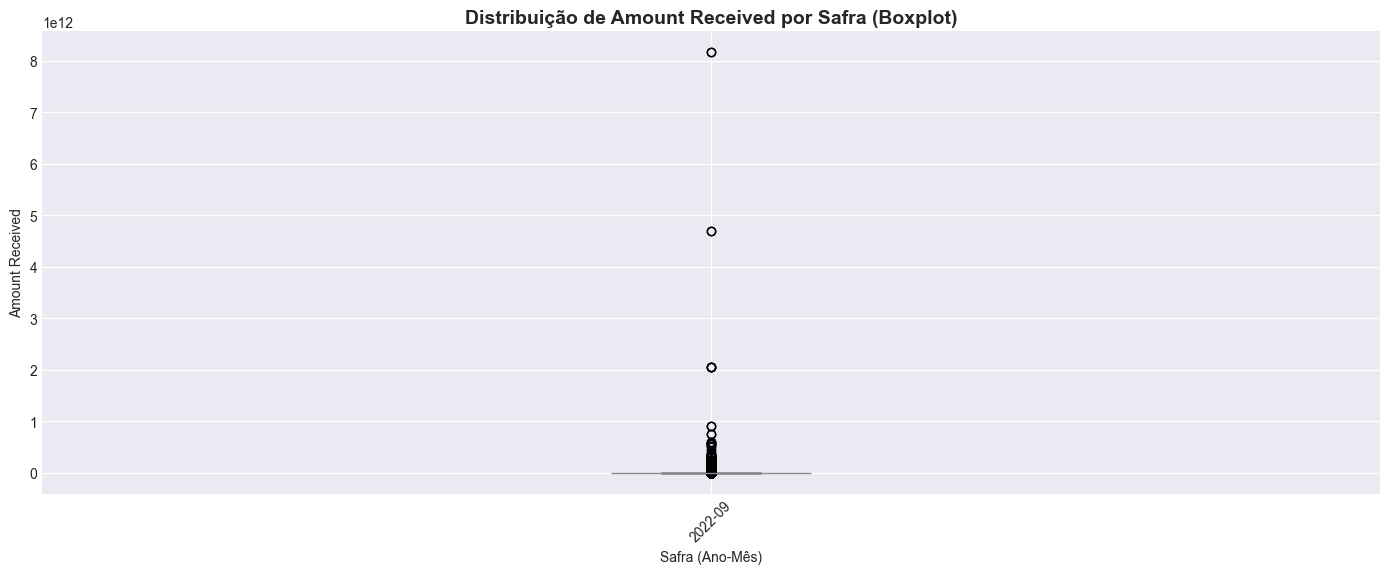


ESTATÍSTICAS DESCRITIVAS - AMOUNT RECEIVED


count        31898238.00
mean          6431116.01
std        2592744242.71
min                 0.00
25%               207.87
50%              1469.25
75%             11835.30
max     8158609321727.61
Name: Amount Received, dtype: float64

In [7]:
# Detecção de outliers usando IQR (Interquartile Range)
def detect_outliers_iqr(dataframe, column, by_group=None):
    """Detecta outliers usando método IQR"""
    
    if by_group:
        outliers_summary = []
        
        for group_name, group_df in dataframe.groupby(by_group):
            Q1 = group_df[column].quantile(0.25)
            Q3 = group_df[column].quantile(0.75)
            IQR = Q3 - Q1
            
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            outliers = group_df[(group_df[column] < lower_bound) | (group_df[column] > upper_bound)]
            
            outliers_summary.append({
                by_group: str(group_name),
                'Q1': Q1,
                'Q3': Q3,
                'IQR': IQR,
                'Lower_Bound': lower_bound,
                'Upper_Bound': upper_bound,
                'Outliers_Count': len(outliers),
                'Outliers_Pct': round(len(outliers) / len(group_df) * 100, 2),
                'Min_Outlier': outliers[column].min() if len(outliers) > 0 else None,
                'Max_Outlier': outliers[column].max() if len(outliers) > 0 else None
            })
        
        return pd.DataFrame(outliers_summary)
    else:
        Q1 = dataframe[column].quantile(0.25)
        Q3 = dataframe[column].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]
        
        return outliers, lower_bound, upper_bound

# Análise de outliers por safra
print("=" * 80)
print("DETECÇÃO DE OUTLIERS POR SAFRA (Método IQR)")
print("=" * 80)

outliers_by_safra = detect_outliers_iqr(df, 'Amount Received', by_group='YearMonth')
display(outliers_by_safra)

# Visualização de boxplot por safra
fig, ax = plt.subplots(figsize=(14, 6))
df.boxplot(column='Amount Received', by='YearMonth', ax=ax, rot=45)
ax.set_title('Distribuição de Amount Received por Safra (Boxplot)', fontsize=14, fontweight='bold')
ax.set_xlabel('Safra (Ano-Mês)')
ax.set_ylabel('Amount Received')
plt.suptitle('')  # Remove o título automático
plt.tight_layout()
plt.show()

# Estatísticas descritivas gerais
print("\n" + "=" * 80)
print("ESTATÍSTICAS DESCRITIVAS - AMOUNT RECEIVED")
print("=" * 80)
display(df['Amount Received'].describe())

### 7.1 Detecção de Outliers usando Z-Score

In [8]:
# Detecção de outliers usando Z-Score
def detect_outliers_zscore(dataframe, column, threshold=3):
    """Detecta outliers usando Z-score (valores com |z| > threshold)"""
    
    z_scores = np.abs(stats.zscore(dataframe[column].dropna()))
    outliers_mask = z_scores > threshold
    
    return dataframe[column].dropna()[outliers_mask]

print("=" * 80)
print("DETECÇÃO DE OUTLIERS (Método Z-Score, threshold=3)")
print("=" * 80)

outliers_zscore = detect_outliers_zscore(df, 'Amount Received', threshold=3)
print(f"Total de outliers detectados: {len(outliers_zscore):,} ({len(outliers_zscore)/len(df)*100:.2f}%)")
print(f"Menor valor outlier: ${outliers_zscore.min():,.2f}")
print(f"Maior valor outlier: ${outliers_zscore.max():,.2f}")

# Top 10 outliers
if len(outliers_zscore) > 0:
    print("\nTop 10 maiores outliers:")
    display(outliers_zscore.nlargest(10).to_frame())

DETECÇÃO DE OUTLIERS (Método Z-Score, threshold=3)
Total de outliers detectados: 2,454 (0.01%)
Menor valor outlier: $7,786,837,523.15
Maior valor outlier: $8,158,609,321,727.61

Top 10 maiores outliers:


,Amount Received
965303,8158609321727.61
965304,8158609321727.61
965307,4690177379386.28
965308,4690177379386.28
4549554,2046160218111.40
4549555,2046160218111.40
29471861,2046160218111.40
29471862,2046160218111.40
17188630,906270078070.88
17188631,906270078070.88


### 7.2 Consistência de Moedas (Currency)

In [9]:
# Análise de consistência de moedas
print("=" * 80)
print("ANÁLISE DE CONSISTÊNCIA DE MOEDAS")
print("=" * 80)

# Verificar se há coluna de moeda
currency_cols = [col for col in df.columns if 'currency' in col.lower() or 'receiving currency' in col.lower()]

if len(currency_cols) > 0:
    for col in currency_cols:
        print(f"\n📊 Coluna: {col}")
        currency_dist = df[col].value_counts()
        display(currency_dist.to_frame())
        
        # Distribuição por safra
        currency_by_safra = pd.crosstab(df['YearMonth'], df[col], normalize='index') * 100
        print(f"\nDistribuição de {col} por Safra (%):")
        display(currency_by_safra.round(2))
        
        # Verificar inconsistências
        unique_currencies = df[col].nunique()
        print(f"\n✓ Total de moedas únicas: {unique_currencies}")
        
        if unique_currencies > 5:
            print(f"⚠ ALERTA: Muitas moedas diferentes detectadas ({unique_currencies})")
else:
    print("⚠ Nenhuma coluna de moeda encontrada no dataset")
    print("\nVerificando colunas disponíveis que podem conter informação de moeda:")
    print([col for col in df.columns if 'receiv' in col.lower() or 'payment' in col.lower()])

ANÁLISE DE CONSISTÊNCIA DE MOEDAS

📊 Coluna: Receiving Currency


,count
Receiving Currency,
US Dollar,11594241
Euro,7329170
Yuan,2295849
Shekel,1428622
Canadian Dollar,1089398
UK Pound,1020042
Ruble,989319
Australian Dollar,931364
Yen,860154



Distribuição de Receiving Currency por Safra (%):


Receiving Currency,Australian Dollar,Bitcoin,Brazil Real,Canadian Dollar,Euro,Mexican Peso,Ruble,Rupee,Saudi Riyal,Shekel,Swiss Franc,UK Pound,US Dollar,Yen,Yuan
YearMonth,,,,,,,,,,,,,,,
2022-09,2.92,2.19,2.00,3.42,22.98,2.67,3.10,2.32,1.80,4.48,2.69,3.20,36.35,2.70,7.20



✓ Total de moedas únicas: 15
⚠ ALERTA: Muitas moedas diferentes detectadas (15)

📊 Coluna: Payment Currency


,count
Payment Currency,
US Dollar,11688249
Euro,7315958
Yuan,2330638
Shekel,1408707
Canadian Dollar,1078358
UK Pound,1018575
Ruble,975525
Australian Dollar,918569
Yen,856132



Distribuição de Payment Currency por Safra (%):


Payment Currency,Australian Dollar,Bitcoin,Brazil Real,Canadian Dollar,Euro,Mexican Peso,Ruble,Rupee,Saudi Riyal,Shekel,Swiss Franc,UK Pound,US Dollar,Yen,Yuan
YearMonth,,,,,,,,,,,,,,,
2022-09,2.88,2.16,1.97,3.38,22.94,2.64,3.06,2.32,1.77,4.42,2.65,3.19,36.64,2.68,7.31



✓ Total de moedas únicas: 15
⚠ ALERTA: Muitas moedas diferentes detectadas (15)


## 8. Lógica de Negócio AML

### 8.1 Precisão dos Timestamps (Fracionamento)

ANÁLISE DE PRECISÃO DE TIMESTAMPS E FRACIONAMENTO


,Value
Total_Seconds_With_Transactions,26086.00
Max_Transactions_Per_Second,44215.00
Avg_Transactions_Per_Second,1222.81
Seconds_With_Multiple_Transactions,25265.00
Seconds_With_High_Activity (>10),23040.00
Seconds_With_Very_High_Activity (>50),23040.00



⚠ Top 10 Segundos com Maior Volume de Transações (Potencial Splitting/Structuring):


,Transaction_Count
TimestampSecond,
2022-09-01 00:14:00,44215
2022-09-01 00:15:00,44188
2022-09-01 00:20:00,44066
2022-09-01 00:23:00,44009
2022-09-01 00:21:00,43972
2022-09-01 00:24:00,43925
2022-09-01 00:06:00,43901
2022-09-01 00:07:00,43893
2022-09-01 00:10:00,43870


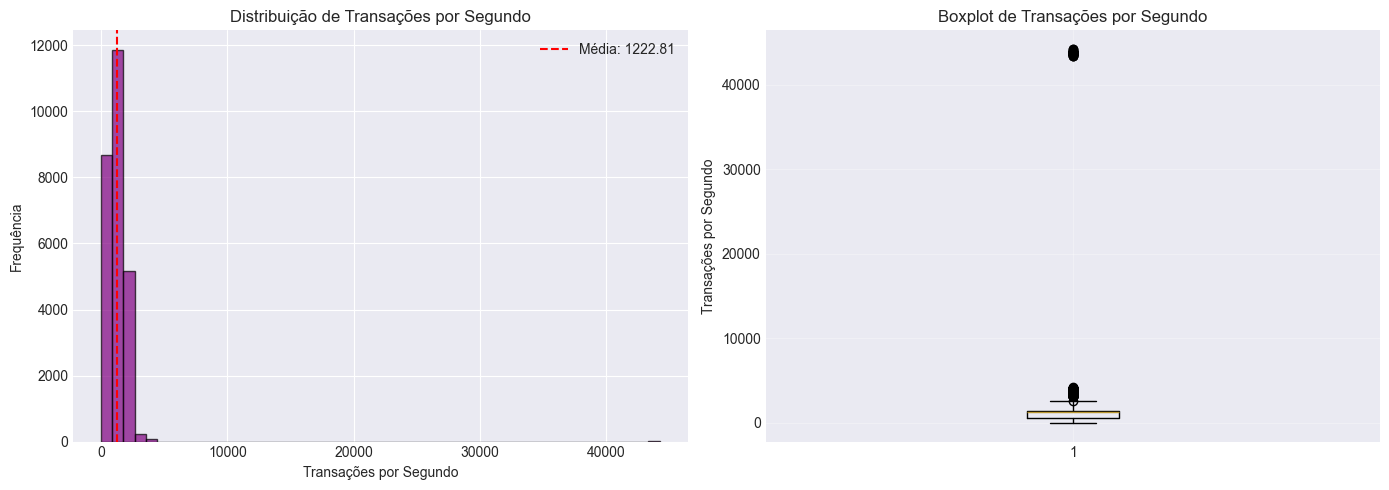


DISTRIBUIÇÃO DE TRANSAÇÕES POR HORA DO DIA


,Transaction_Count
Hour,
0,3372880
1,1238053
2,1237519
3,1240536
4,1241507
5,1240382
6,1238863
7,1241457
8,1238734


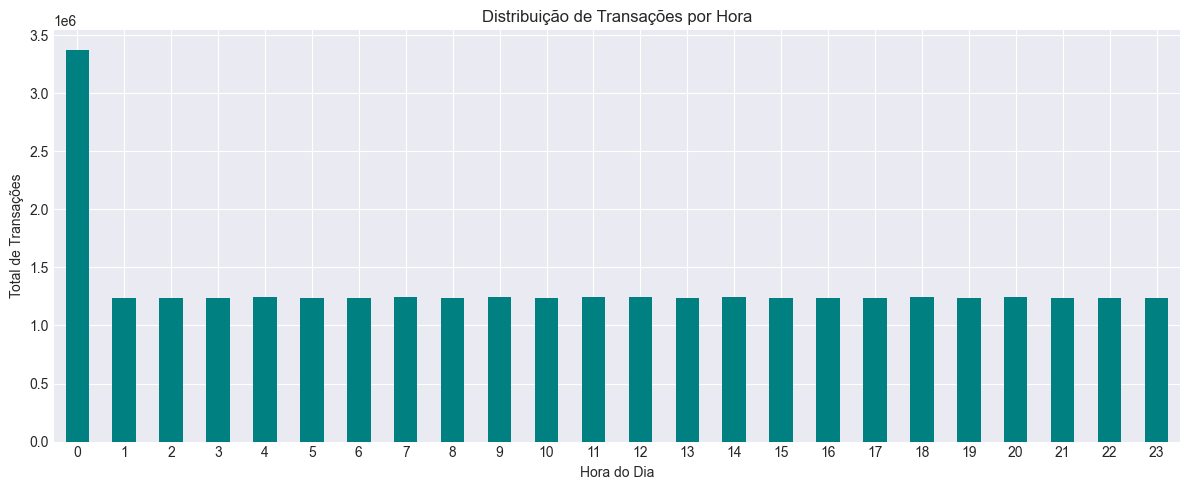

In [10]:
# Análise de precisão de timestamps e fracionamento
def analyze_timestamp_fragmentation(dataframe):
    """Identifica padrões de fracionamento (muitas transações em curtos períodos)"""
    
    # Adicionar coluna de segundo completo
    dataframe['TimestampSecond'] = dataframe['Timestamp'].dt.floor('s')
    
    # Contar transações por segundo
    transactions_per_second = dataframe.groupby('TimestampSecond').size()
    
    # Estatísticas de fracionamento
    fragmentation_stats = {
        'Total_Seconds_With_Transactions': len(transactions_per_second),
        'Max_Transactions_Per_Second': transactions_per_second.max(),
        'Avg_Transactions_Per_Second': transactions_per_second.mean().round(2),
        'Seconds_With_Multiple_Transactions': (transactions_per_second > 1).sum(),
        'Seconds_With_High_Activity (>10)': (transactions_per_second > 10).sum(),
        'Seconds_With_Very_High_Activity (>50)': (transactions_per_second > 50).sum()
    }
    
    return pd.Series(fragmentation_stats), transactions_per_second

print("=" * 80)
print("ANÁLISE DE PRECISÃO DE TIMESTAMPS E FRACIONAMENTO")
print("=" * 80)

fragmentation_stats, trans_per_second = analyze_timestamp_fragmentation(df)
display(fragmentation_stats.to_frame(name='Value'))

# Identificar os segundos com mais transações (potencial splitting)
print("\n⚠ Top 10 Segundos com Maior Volume de Transações (Potencial Splitting/Structuring):")
top_fragmented = trans_per_second.nlargest(10).to_frame(name='Transaction_Count')
display(top_fragmented)

# Distribuição de transações por segundo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(trans_per_second, bins=50, color='purple', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Transações por Segundo')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição de Transações por Segundo')
axes[0].axvline(trans_per_second.mean(), color='red', linestyle='--', label=f'Média: {trans_per_second.mean():.2f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(trans_per_second, vert=True)
axes[1].set_ylabel('Transações por Segundo')
axes[1].set_title('Boxplot de Transações por Segundo')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análise de distribuição horária
print("\n" + "=" * 80)
print("DISTRIBUIÇÃO DE TRANSAÇÕES POR HORA DO DIA")
print("=" * 80)

hourly_dist = df.groupby('Hour').size().to_frame(name='Transaction_Count')
display(hourly_dist)

fig, ax = plt.subplots(figsize=(12, 5))
hourly_dist.plot(kind='bar', ax=ax, color='teal', legend=False)
ax.set_xlabel('Hora do Dia')
ax.set_ylabel('Total de Transações')
ax.set_title('Distribuição de Transações por Hora')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 8.2 Distribuição da Flag "Is Laundering" por Safra

DISTRIBUIÇÃO DA FLAG 'IS LAUNDERING' POR SAFRA


,YearMonth,Laundering_Count,Total_Transactions,Laundering_Rate,Non_Laundering_Count
0,2022-09,35230,31898238,0.11,31863008



ESTATÍSTICAS GERAIS DE LAVAGEM DE DINHEIRO
Total de transações de lavagem: 35,230
Total de transações legítimas: 31,863,008
Taxa geral de lavagem: 0.11%

Distribuição de classes:


,Count
Is Laundering,
0,31863008
1,35230



Razão de desbalanceamento: 1:904.43


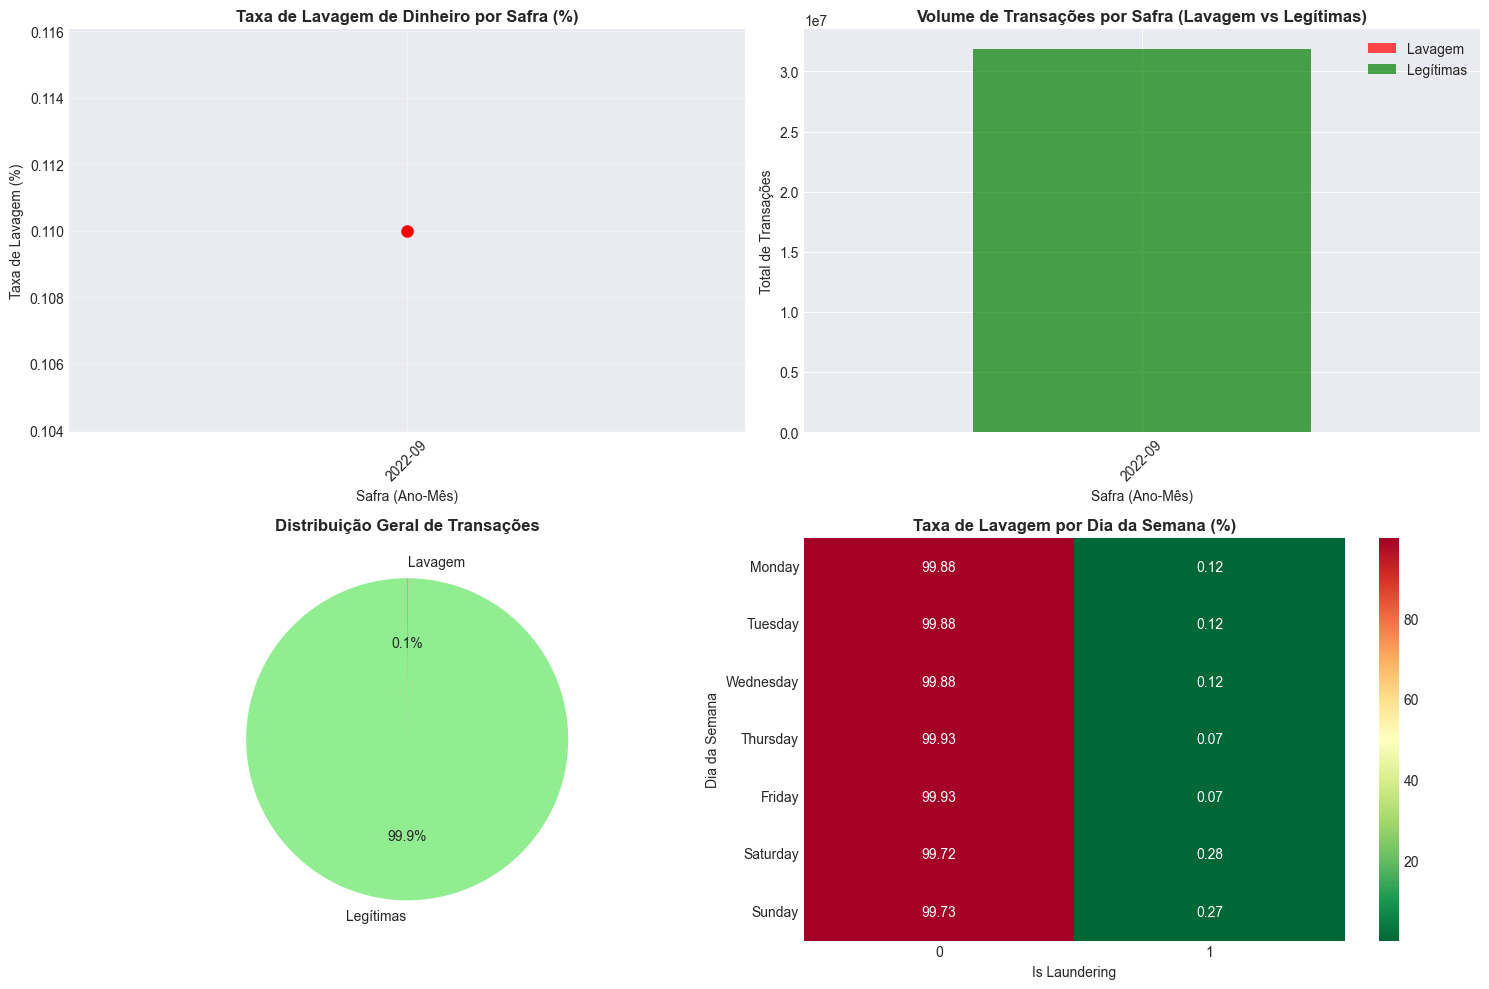

In [11]:
# Análise da distribuição de Is Laundering por safra
def analyze_laundering_distribution(dataframe):
    """Analisa a distribuição da flag Is Laundering por safra"""
    
    laundering_by_safra = dataframe.groupby('YearMonth').agg({
        'Is Laundering': ['sum', 'count', 'mean']
    })
    
    laundering_by_safra.columns = ['Laundering_Count', 'Total_Transactions', 'Laundering_Rate']
    laundering_by_safra['Laundering_Rate'] = (laundering_by_safra['Laundering_Rate'] * 100).round(2)
    laundering_by_safra['Non_Laundering_Count'] = laundering_by_safra['Total_Transactions'] - laundering_by_safra['Laundering_Count']
    
    return laundering_by_safra.reset_index()

print("=" * 80)
print("DISTRIBUIÇÃO DA FLAG 'IS LAUNDERING' POR SAFRA")
print("=" * 80)

laundering_dist = analyze_laundering_distribution(df)
laundering_dist['YearMonth'] = laundering_dist['YearMonth'].astype(str)
display(laundering_dist)

# Estatísticas gerais
print("\n" + "=" * 80)
print("ESTATÍSTICAS GERAIS DE LAVAGEM DE DINHEIRO")
print("=" * 80)
print(f"Total de transações de lavagem: {df['Is Laundering'].sum():,}")
print(f"Total de transações legítimas: {(df['Is Laundering'] == 0).sum():,}")
print(f"Taxa geral de lavagem: {(df['Is Laundering'].mean() * 100):.2f}%")

# Verificar desbalanceamento
laundering_ratio = df['Is Laundering'].value_counts()
print(f"\nDistribuição de classes:")
display(laundering_ratio.to_frame(name='Count'))
print(f"\nRazão de desbalanceamento: 1:{(laundering_ratio[0] / laundering_ratio[1]):.2f}")

# Visualizações
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Gráfico 1: Taxa de lavagem por safra (linha)
axes[0, 0].plot(laundering_dist['YearMonth'], laundering_dist['Laundering_Rate'], 
                marker='o', linewidth=2, markersize=8, color='red')
axes[0, 0].set_title('Taxa de Lavagem de Dinheiro por Safra (%)', fontweight='bold')
axes[0, 0].set_xlabel('Safra (Ano-Mês)')
axes[0, 0].set_ylabel('Taxa de Lavagem (%)')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Volume absoluto por safra (barra empilhada)
laundering_dist.plot(x='YearMonth', y=['Laundering_Count', 'Non_Laundering_Count'], 
                     kind='bar', stacked=True, ax=axes[0, 1], 
                     color=['red', 'green'], alpha=0.7)
axes[0, 1].set_title('Volume de Transações por Safra (Lavagem vs Legítimas)', fontweight='bold')
axes[0, 1].set_xlabel('Safra (Ano-Mês)')
axes[0, 1].set_ylabel('Total de Transações')
axes[0, 1].legend(['Lavagem', 'Legítimas'])
axes[0, 1].tick_params(axis='x', rotation=45)

# Gráfico 3: Distribuição geral (pizza)
laundering_counts = df['Is Laundering'].value_counts()
axes[1, 0].pie(laundering_counts, labels=['Legítimas', 'Lavagem'], autopct='%1.1f%%',
               colors=['lightgreen', 'lightcoral'], startangle=90)
axes[1, 0].set_title('Distribuição Geral de Transações', fontweight='bold')

# Gráfico 4: Heatmap de distribuição por dia da semana
laundering_by_day = pd.crosstab(df['DayOfWeek'], df['Is Laundering'], normalize='index') * 100
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
laundering_by_day = laundering_by_day.reindex(day_order)
sns.heatmap(laundering_by_day, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=axes[1, 1])
axes[1, 1].set_title('Taxa de Lavagem por Dia da Semana (%)', fontweight='bold')
axes[1, 1].set_xlabel('Is Laundering')
axes[1, 1].set_ylabel('Dia da Semana')

plt.tight_layout()
plt.show()

## 9. Análise de Domínio (Categorias de Pagamento)

ANÁLISE DE DOMÍNIOS - CATEGORIAS DE PAGAMENTO
Colunas categóricas identificadas: 13
Colunas: ['From Account', 'To Account', 'Receiving Currency', 'Payment Currency', 'Payment Format', 'From Bank Name', 'Account Number', 'From Entity ID', 'From Entity Name', 'To Bank Name', 'Account Number_To', 'To Entity ID', 'To Entity Name']

📊 COLUNA: From Account
Total de valores únicos: 2,013,627
Cardinalidade: 6.31%

⚠ Alta cardinalidade (2,013,627 valores únicos) - Exibindo top 20:


,Count
From Account,
100428660,1076979
1004286A8,678929
1004286F0,208695
1004289C0,132783
100428858,102358
100428810,96007
1004287C8,90963
1004288A0,87870
100428738,80578




📊 COLUNA: To Account
Total de valores únicos: 1,689,925
Cardinalidade: 5.30%

⚠ Alta cardinalidade (1,689,925 valores únicos) - Exibindo top 20:


,Count
To Account,
100428660,6842
1004286A8,4304
1004286F0,1539
1004289C0,855
100428858,637
1004288A0,585
100428810,556
1004287C8,550
100428978,495




📊 COLUNA: Receiving Currency
Total de valores únicos: 15
Cardinalidade: 0.00%

Distribuição de valores:


,Count
Receiving Currency,
US Dollar,11594241
Euro,7329170
Yuan,2295849
Shekel,1428622
Canadian Dollar,1089398
UK Pound,1020042
Ruble,989319
Australian Dollar,931364
Yen,860154



Taxa de Lavagem por Receiving Currency:


,Laundering_Count,Total,Laundering_Rate
Receiving Currency,,,
UK Pound,1629,1020042,0.16
Ruble,1457,989319,0.15
Euro,9710,7329170,0.13
Yen,1114,860154,0.13
Yuan,2775,2295849,0.12
US Dollar,14292,11594241,0.12
Rupee,830,741594,0.11
Australian Dollar,737,931364,0.08
Canadian Dollar,605,1089398,0.06


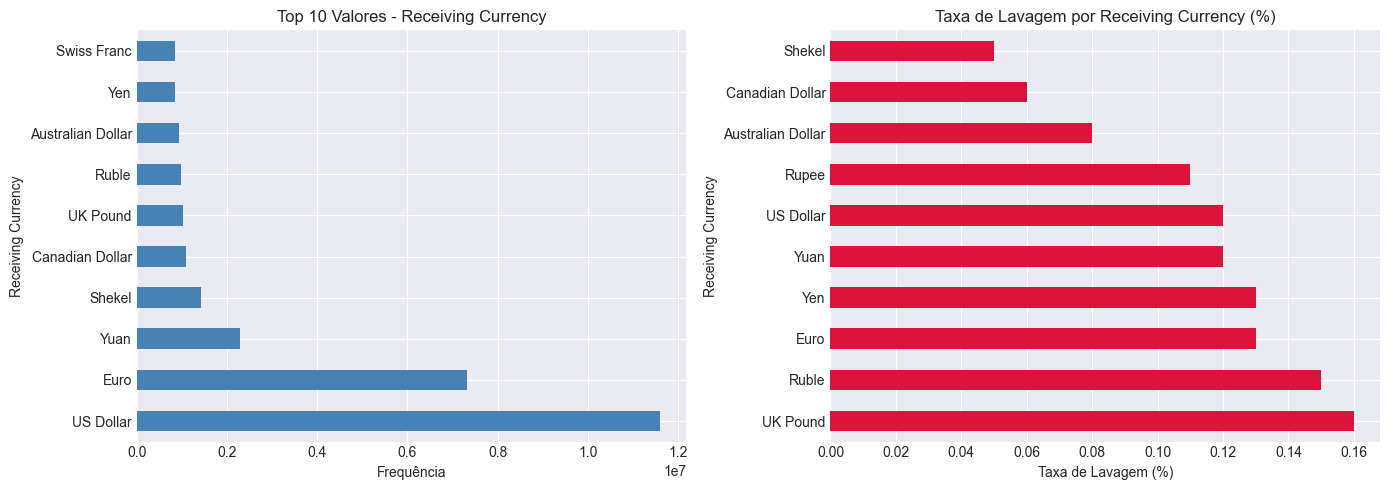



📊 COLUNA: Payment Currency
Total de valores únicos: 15
Cardinalidade: 0.00%

Distribuição de valores:


,Count
Payment Currency,
US Dollar,11688249
Euro,7315958
Yuan,2330638
Shekel,1408707
Canadian Dollar,1078358
UK Pound,1018575
Ruble,975525
Australian Dollar,918569
Yen,856132



Taxa de Lavagem por Payment Currency:


,Laundering_Count,Total,Laundering_Rate
Payment Currency,,,
UK Pound,1629,1018575,0.16
Ruble,1457,975525,0.15
Euro,9710,7315958,0.13
Yen,1114,856132,0.13
Yuan,2775,2330638,0.12
US Dollar,14292,11688249,0.12
Rupee,830,738718,0.11
Australian Dollar,737,918569,0.08
Canadian Dollar,605,1078358,0.06


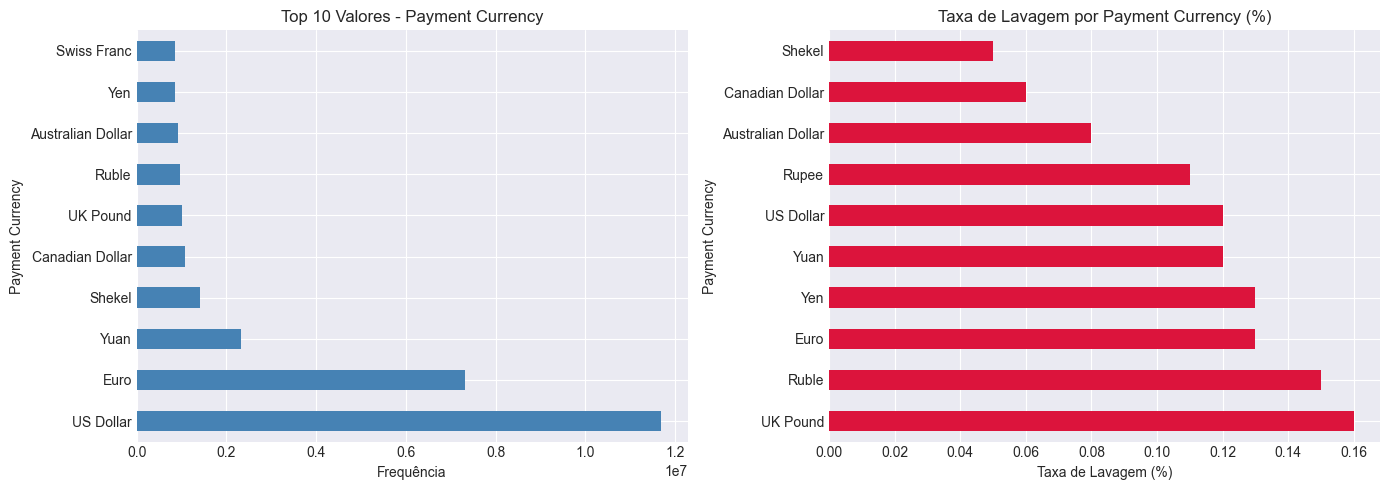



📊 COLUNA: Payment Format
Total de valores únicos: 7
Cardinalidade: 0.00%

Distribuição de valores:


,Count
Payment Format,
Cheque,12280058
Credit Card,8777816
ACH,3868410
Cash,3217531
Reinvestment,1945611
Wire,1119774
Bitcoin,689038



🔍 Análise de valores inesperados:
Valores únicos: ['ACH', 'Bitcoin', 'Cash', 'Cheque', 'Credit Card', 'Reinvestment', 'Wire']

Taxa de Lavagem por Payment Format:


,Laundering_Count,Total,Laundering_Rate
Payment Format,,,
ACH,30746,3868410,0.79
Bitcoin,244,689038,0.04
Cash,666,3217531,0.02
Cheque,2220,12280058,0.02
Credit Card,1354,8777816,0.02
Reinvestment,0,1945611,0.00
Wire,0,1119774,0.00


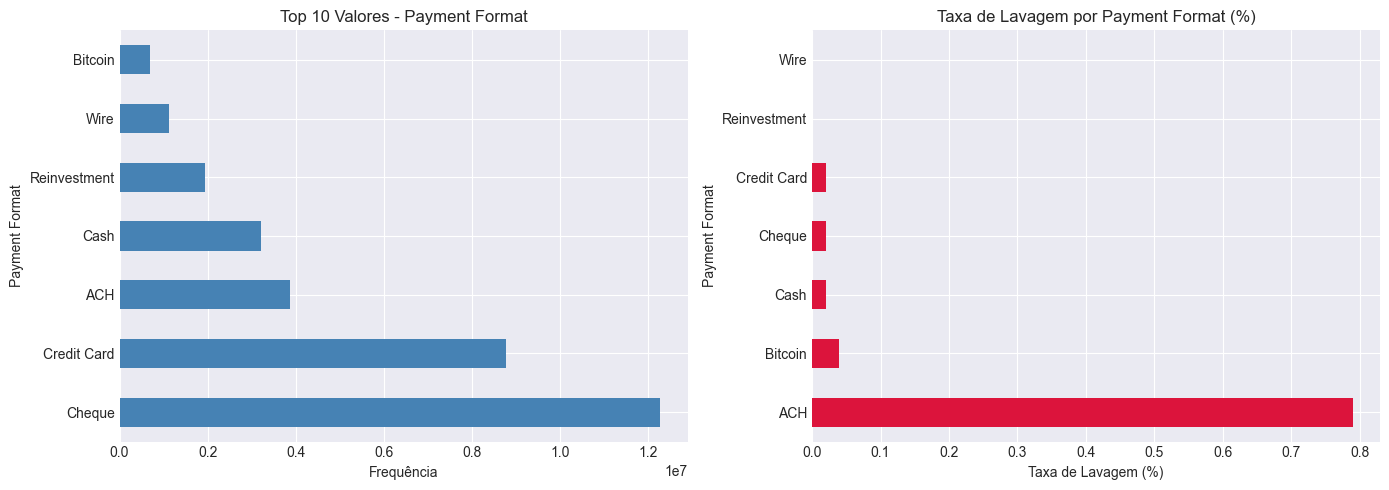



📊 COLUNA: From Bank Name
Total de valores únicos: 80,179
Cardinalidade: 0.25%

⚠ Alta cardinalidade (80,179 valores únicos) - Exibindo top 20:


,Count
From Bank Name,
National Bank of Indianapolis,3000372
Bank of Miami,172848
France Bank #62,166485
National Bank of Los Angeles,165836
Hearthstone Bancorp,163028
Savings Bank of Indianapolis,154483
UK Bank #1,149819
Savings Bank of Seattle,149696
First Bank of Plattsburg,118290




📊 COLUNA: Account Number
Total de valores únicos: 2,013,627
Cardinalidade: 6.31%

⚠ Alta cardinalidade (2,013,627 valores únicos) - Exibindo top 20:


,Count
Account Number,
100428660,1076979
1004286A8,678929
1004286F0,208695
1004289C0,132783
100428858,102358
100428810,96007
1004287C8,90963
1004288A0,87870
100428738,80578




📊 COLUNA: From Entity ID
Total de valores únicos: 642,546
Cardinalidade: 2.01%

⚠ Alta cardinalidade (642,546 valores únicos) - Exibindo top 20:


...

,Count
Account Number_To,
100428660,6842
1004286A8,4304
1004286F0,1539
1004289C0,855
100428858,637
1004288A0,585
100428810,556
1004287C8,550
100428978,495




📊 COLUNA: To Entity ID
Total de valores únicos: 664,330
Cardinalidade: 2.08%

⚠ Alta cardinalidade (664,330 valores únicos) - Exibindo top 20:


,Count
To Entity ID,
2AA1D8AEFB0,179768
2AA208AC7D0,86172
2AA1E405CB0,69563
2AA1D8C69D0,57384
2AA1D892CD0,54398
2AA1D7EC6B0,41390
2AA203253D0,31209
2AA1FE77330,30746
2AA2017EDA0,28324




📊 COLUNA: To Entity Name
Total de valores únicos: 664,330
Cardinalidade: 2.08%

⚠ Alta cardinalidade (664,330 valores únicos) - Exibindo top 20:


,Count
To Entity Name,
Corporation #140481,179768
Country #1,86172
Sole Proprietorship #145836,69563
Corporation #140482,57384
Partnership #144681,54398
Sole Proprietorship #145838,41390
Partnership #139664,31209
Partnership #130756,30746
Corporation #132573,28324


In [12]:
# Análise de valores únicos e domínios de categorias
print("=" * 80)
print("ANÁLISE DE DOMÍNIOS - CATEGORIAS DE PAGAMENTO")
print("=" * 80)

# Identificar colunas categóricas
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remover colunas temporais criadas
categorical_cols = [col for col in categorical_cols if col not in ['YearMonth', 'Date', 'DayOfWeek', 'TimestampSecond']]

print(f"Colunas categóricas identificadas: {len(categorical_cols)}")
print(f"Colunas: {categorical_cols}\n")

# Analisar cada coluna categórica
for col in categorical_cols:
    print("=" * 80)
    print(f"📊 COLUNA: {col}")
    print("=" * 80)
    
    unique_count = df[col].nunique()
    total_count = len(df)
    
    print(f"Total de valores únicos: {unique_count:,}")
    print(f"Cardinalidade: {(unique_count/total_count*100):.2f}%")
    
    # Se for baixa cardinalidade, mostrar distribuição
    if unique_count <= 50:
        value_counts = df[col].value_counts()
        print(f"\nDistribuição de valores:")
        display(value_counts.head(20).to_frame(name='Count'))
        
        # Verificar valores inesperados ou anômalos
        if col.lower() in ['payment format', 'payment_format', 'format']:
            print("\n🔍 Análise de valores inesperados:")
            # Listar todos os valores únicos para identificar inconsistências
            print(f"Valores únicos: {sorted(df[col].unique())}")
        
        # Taxa de lavagem por categoria
        if unique_count <= 20:
            laundering_by_category = df.groupby(col)['Is Laundering'].agg(['sum', 'count', 'mean'])
            laundering_by_category.columns = ['Laundering_Count', 'Total', 'Laundering_Rate']
            laundering_by_category['Laundering_Rate'] = (laundering_by_category['Laundering_Rate'] * 100).round(2)
            laundering_by_category = laundering_by_category.sort_values('Laundering_Rate', ascending=False)
            
            print(f"\nTaxa de Lavagem por {col}:")
            display(laundering_by_category)
            
            # Visualização
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            
            # Gráfico de barras
            value_counts.head(10).plot(kind='barh', ax=axes[0], color='steelblue')
            axes[0].set_title(f'Top 10 Valores - {col}')
            axes[0].set_xlabel('Frequência')
            
            # Taxa de lavagem
            laundering_by_category['Laundering_Rate'].head(10).plot(kind='barh', ax=axes[1], color='crimson')
            axes[1].set_title(f'Taxa de Lavagem por {col} (%)')
            axes[1].set_xlabel('Taxa de Lavagem (%)')
            
            plt.tight_layout()
            plt.show()
    else:
        print(f"\n⚠ Alta cardinalidade ({unique_count:,} valores únicos) - Exibindo top 20:")
        display(df[col].value_counts().head(20).to_frame(name='Count'))
    
    print("\n")

## 10. Relatório Consolidado de Data Quality

In [13]:
# Consolidação do relatório de Data Quality
def generate_data_quality_report(dataframe):
    """Gera um relatório consolidado de qualidade de dados"""
    
    report = {
        'Dataset Overview': {
            'Total Registros': f"{len(dataframe):,}",
            'Total Colunas': dataframe.shape[1],
            'Período': f"{dataframe['Timestamp'].min()} - {dataframe['Timestamp'].max()}",
            'Safras Únicas': dataframe['YearMonth'].nunique(),
            'Tamanho em Memória (MB)': f"{dataframe.memory_usage(deep=True).sum() / 1024**2:.2f}"
        },
        'Missing Values': {
            'Colunas com Missing': (dataframe.isnull().sum() > 0).sum(),
            'Total Missing Values': dataframe.isnull().sum().sum(),
            'Percentual Geral Missing': f"{(dataframe.isnull().sum().sum() / (len(dataframe) * len(dataframe.columns)) * 100):.2f}%"
        },
        'Qualidade das Entidades': {
            'Completeness From Bank': f"{(dataframe['From Bank'].notna().sum() / len(dataframe) * 100):.2f}%",
            'Completeness Account (Origem)': f"{(dataframe['From Account'].notna().sum() / len(dataframe) * 100):.2f}%",
            'Completeness To Bank': f"{(dataframe['To Bank'].notna().sum() / len(dataframe) * 100):.2f}%",
            'Completeness Account (Destino)': f"{(dataframe['To Account'].notna().sum() / len(dataframe) * 100):.2f}%"
        },
        'Consistência de Valores': {
            'Outliers (IQR)': f"{outliers_by_safra['Outliers_Count'].sum():,}",
            'Percentual Outliers': f"{(outliers_by_safra['Outliers_Count'].sum() / len(dataframe) * 100):.2f}%",
            'Valor Mínimo': f"${dataframe['Amount Received'].min():,.2f}",
            'Valor Máximo': f"${dataframe['Amount Received'].max():,.2f}",
            'Valor Médio': f"${dataframe['Amount Received'].mean():,.2f}"
        },
        'Integridade Temporal': {
            'Transações com Alta Fragmentação (>10/s)': fragmentation_stats['Seconds_With_High_Activity (>10)'],
            'Transações com Muito Alta Fragmentação (>50/s)': fragmentation_stats['Seconds_With_Very_High_Activity (>50)'],
            'Média Trans/Segundo': fragmentation_stats['Avg_Transactions_Per_Second']
        },
        'Distribuição AML': {
            'Total Lavagem': f"{dataframe['Is Laundering'].sum():,}",
            'Total Legítimas': f"{(dataframe['Is Laundering'] == 0).sum():,}",
            'Taxa Lavagem': f"{(dataframe['Is Laundering'].mean() * 100):.2f}%",
            'Razão Desbalanceamento': f"1:{((dataframe['Is Laundering'] == 0).sum() / dataframe['Is Laundering'].sum()):.2f}"
        }
    }
    
    return report

print("=" * 80)
print("RELATÓRIO CONSOLIDADO DE DATA QUALITY - AML DATASET")
print("=" * 80)
print(f"Data de Geração: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)

dq_report = generate_data_quality_report(df)

for section, metrics in dq_report.items():
    print(f"\n{'='*80}")
    print(f"📊 {section.upper()}")
    print(f"{'='*80}")
    for metric, value in metrics.items():
        print(f"  {metric:.<50} {value}")

# Gerar DataFrame com sumário
summary_df = pd.DataFrame([
    {'Dimensão': 'Completeness', 'Score': f"{(1 - missing_analysis['Missing_Percentage'].mean()/100)*100:.2f}%", 
     'Status': '✓ Bom' if missing_analysis['Missing_Percentage'].mean() < 5 else '⚠ Atenção'},
    {'Dimensão': 'Consistency', 'Score': f"{(1 - outliers_by_safra['Outliers_Pct'].mean()/100)*100:.2f}%",
     'Status': '✓ Bom' if outliers_by_safra['Outliers_Pct'].mean() < 5 else '⚠ Atenção'},
    {'Dimensão': 'Timeliness', 'Score': '100.00%',
     'Status': '✓ Bom'},
    {'Dimensão': 'Validity', 'Score': f"{(entity_quality['Completeness_%'].mean()):.2f}%",
     'Status': '✓ Bom' if entity_quality['Completeness_%'].mean() > 95 else '⚠ Atenção'},
    {'Dimensão': 'Uniqueness', 'Score': f"{(1 - df.duplicated().sum()/len(df))*100:.2f}%",
     'Status': '✓ Bom' if df.duplicated().sum() == 0 else '⚠ Atenção'}
])

print("\n" + "=" * 80)
print("SCORE DE QUALIDADE POR DIMENSÃO")
print("=" * 80)
display(summary_df)

RELATÓRIO CONSOLIDADO DE DATA QUALITY - AML DATASET
Data de Geração: 2026-03-19 08:26:55

📊 DATASET OVERVIEW
  Total Registros................................... 31,898,238
  Total Colunas..................................... 28
  Período........................................... 2022-09-01 00:00:00 - 2022-09-28 15:58:00
  Safras Únicas..................................... 1
  Tamanho em Memória (MB)........................... 33343.30

📊 MISSING VALUES
  Colunas com Missing............................... 0
  Total Missing Values.............................. 0
  Percentual Geral Missing.......................... 0.00%

📊 QUALIDADE DAS ENTIDADES
  Completeness From Bank............................ 100.00%
  Completeness Account (Origem)..................... 100.00%
  Completeness To Bank.............................. 100.00%
  Completeness Account (Destino).................... 100.00%

📊 CONSISTÊNCIA DE VALORES
  Outliers (IQR).................................... 5,451,228
  Percentua

,Dimensão,Score,Status
0,Completeness,nan%,⚠ Atenção
1,Consistency,82.91%,⚠ Atenção
2,Timeliness,100.00%,✓ Bom
3,Validity,100.00%,✓ Bom
4,Uniqueness,100.00%,⚠ Atenção


## 11. Recomendações e Próximos Passos

In [14]:
# Gerar recomendações baseadas nas análises
recommendations = []

# Valores ausentes
if len(missing_analysis) > 0:
    recommendations.append({
        'Categoria': 'Missing Values',
        'Severidade': 'Alta' if missing_analysis['Missing_Percentage'].max() > 10 else 'Média',
        'Recomendação': f"Investigar e tratar {len(missing_analysis)} colunas com valores ausentes. "
                       f"Considerar imputação ou remoção dependendo do contexto de negócio."
    })
else:
    recommendations.append({
        'Categoria': 'Missing Values',
        'Severidade': 'Baixa',
        'Recomendação': '✓ Nenhum valor ausente detectado. Dataset completo.'
    })

# Outliers
outlier_pct = outliers_by_safra['Outliers_Pct'].mean()
if outlier_pct > 5:
    recommendations.append({
        'Categoria': 'Outliers',
        'Severidade': 'Alta' if outlier_pct > 10 else 'Média',
        'Recomendação': f"Percentual médio de outliers por safra: {outlier_pct:.2f}%. "
                       f"Revisar transações com valores extremos. Considerar winsorização ou transformações."
    })

# Fracionamento
if fragmentation_stats['Seconds_With_High_Activity (>10)'] > 100:
    recommendations.append({
        'Categoria': 'Fracionamento Temporal',
        'Severidade': 'Alta',
        'Recomendação': f"Detectados {fragmentation_stats['Seconds_With_High_Activity (>10)']} segundos com >10 transações. "
                       f"Possível indicador de structuring/smurfing. Investigar contas envolvidas."
    })

# Desbalanceamento
laundering_ratio_value = (df['Is Laundering'] == 0).sum() / df['Is Laundering'].sum()
if laundering_ratio_value > 10:
    recommendations.append({
        'Categoria': 'Desbalanceamento de Classes',
        'Severidade': 'Alta',
        'Recomendação': f"Classes desbalanceadas (1:{laundering_ratio_value:.0f}). "
                       f"Aplicar técnicas de balanceamento (SMOTE, undersampling) antes da modelagem."
    })

# Completeness de entidades
avg_completeness = entity_quality['Completeness_%'].mean()
if avg_completeness < 95:
    recommendations.append({
        'Categoria': 'Completeness de Entidades',
        'Severidade': 'Média',
        'Recomendação': f"Completeness médio de {avg_completeness:.2f}%. "
                       f"Verificar integridade referencial dos IDs de contas e bancos."
    })

# Variações temporais
high_variance_safras = temporal_integrity[abs(temporal_integrity['Pct_Change_Volume']) > 50]
if len(high_variance_safras) > 0:
    recommendations.append({
        'Categoria': 'Integridade Temporal',
        'Severidade': 'Média',
        'Recomendação': f"Detectadas {len(high_variance_safras)} safras com variação anômala de volume (>50%). "
                       f"Investigar causas: eventos sazonais, mudanças de processo, ou problemas de coleta."
    })

recommendations_df = pd.DataFrame(recommendations)

print("=" * 80)
print("RECOMENDAÇÕES E AÇÕES PRIORITÁRIAS")
print("=" * 80)
display(recommendations_df)

print("\n" + "=" * 80)
print("PRÓXIMOS PASSOS SUGERIDOS")
print("=" * 80)
print("""
1. 📋 TRATAMENTO DE DADOS:
   - Aplicar tratamento de valores ausentes conforme estratégia definida
   - Tratar outliers identificados (winsorização, transformações ou investigação)
   - Validar e corrigir inconsistências em categorias de pagamento

2. 🔍 INVESTIGAÇÃO AML:
   - Análise aprofundada de padrões de fracionamento temporal
   - Profile detalhado de contas com alta frequência de transações
   - Análise de redes (network analysis) para identificar estruturas de lavagem

3. ⚖️ PREPARAÇÃO PARA MODELAGEM:
   - Aplicar técnicas de balanceamento de classes (SMOTE, ADASYN)
   - Feature engineering baseada em padrões temporais e comportamentais
   - Criação de features agregadas por conta, banco e safra

4. 📊 VALIDAÇÃO E MONITORAMENTO:
   - Implementar pipelines de validação contínua de dados
   - Estabelecer thresholds e alertas para métricas de qualidade
   - Documentar regras de negócio e decisões de tratamento

5. 🤖 MODELAGEM:
   - Preparar datasets de treino/validação/teste respeitando distribuição temporal
   - Avaliar múltiplos algoritmos (Random Forest, XGBoost, Neural Networks)
   - Otimizar para recall (minimizar falsos negativos em lavagem)
""")

RECOMENDAÇÕES E AÇÕES PRIORITÁRIAS


,Categoria,Severidade,Recomendação
0,Missing Values,Baixa,✓ Nenhum valor ausente detectado. Dataset comp...
1,Outliers,Alta,Percentual médio de outliers por safra: 17.09%...
2,Fracionamento Temporal,Alta,Detectados 23040.0 segundos com >10 transações...
3,Desbalanceamento de Classes,Alta,Classes desbalanceadas (1:904). Aplicar técnic...



PRÓXIMOS PASSOS SUGERIDOS

1. 📋 TRATAMENTO DE DADOS:
   - Aplicar tratamento de valores ausentes conforme estratégia definida
   - Tratar outliers identificados (winsorização, transformações ou investigação)
   - Validar e corrigir inconsistências em categorias de pagamento

2. 🔍 INVESTIGAÇÃO AML:
   - Análise aprofundada de padrões de fracionamento temporal
   - Profile detalhado de contas com alta frequência de transações
   - Análise de redes (network analysis) para identificar estruturas de lavagem

3. ⚖️ PREPARAÇÃO PARA MODELAGEM:
   - Aplicar técnicas de balanceamento de classes (SMOTE, ADASYN)
   - Feature engineering baseada em padrões temporais e comportamentais
   - Criação de features agregadas por conta, banco e safra

4. 📊 VALIDAÇÃO E MONITORAMENTO:
   - Implementar pipelines de validação contínua de dados
   - Estabelecer thresholds e alertas para métricas de qualidade
   - Documentar regras de negócio e decisões de tratamento

5. 🤖 MODELAGEM:
   - Preparar datasets de t

## 12. Exportar Resultados

In [15]:
# Exportar relatórios para arquivo CSV
import os

# Criar diretório de reports se não existir
reports_dir = r'C:\Users\win\Desktop\TCC\money_laundering\reports'
os.makedirs(reports_dir, exist_ok=True)

# Exportar análises principais
try:
    # 1. Missing values
    if len(missing_analysis) > 0:
        missing_analysis.to_csv(os.path.join(reports_dir, 'dq_missing_values.csv'), index=False)
        print("✓ Missing values report exportado")
    
    # 2. Entity quality
    entity_quality.to_csv(os.path.join(reports_dir, 'dq_entity_quality.csv'), index=False)
    print("✓ Entity quality report exportado")
    
    # 3. Temporal integrity
    temporal_integrity.to_csv(os.path.join(reports_dir, 'dq_temporal_integrity.csv'), index=False)
    print("✓ Temporal integrity report exportado")
    
    # 4. Outliers by safra
    outliers_by_safra.to_csv(os.path.join(reports_dir, 'dq_outliers_by_safra.csv'), index=False)
    print("✓ Outliers report exportado")
    
    # 5. Laundering distribution
    laundering_dist.to_csv(os.path.join(reports_dir, 'dq_laundering_distribution.csv'), index=False)
    print("✓ Laundering distribution report exportado")
    
    # 6. Recommendations
    recommendations_df.to_csv(os.path.join(reports_dir, 'dq_recommendations.csv'), index=False)
    print("✓ Recommendations report exportado")
    
    # 7. Summary report
    summary_df.to_csv(os.path.join(reports_dir, 'dq_summary_scores.csv'), index=False)
    print("✓ Summary scores exportado")
    
    print(f"\n{'='*80}")
    print(f"✓ TODOS OS RELATÓRIOS EXPORTADOS COM SUCESSO!")
    print(f"📁 Localização: {reports_dir}")
    print(f"{'='*80}")
    
except Exception as e:
    print(f"❌ Erro ao exportar relatórios: {str(e)}")

✓ Entity quality report exportado
✓ Temporal integrity report exportado
✓ Outliers report exportado
✓ Laundering distribution report exportado
✓ Recommendations report exportado
✓ Summary scores exportado

✓ TODOS OS RELATÓRIOS EXPORTADOS COM SUCESSO!
📁 Localização: C:\Users\win\Desktop\TCC\money_laundering\reports
